# Practical Task 2: PyTorch Classification (BCELoss + SGD)

In this practical exercise, you will build and train a small binary classification model using PyTorch. You will learn how to define a neural network, generate synthetic binary labels (a learnable target), use BCELoss for classification, and train the model with the SGD optimizer. 

## Learning Objectives
By the end of this exercise, you will be able to:

    Generate synthetic features and binary targets suitable for classification.
    Define a simple feedforward neural network with Sigmoid output.
    Configure BCELoss and train using optim.SGD.
    Track and interpret training loss during optimization.
    
### Instructions

#### Step 1: Data Generation (Learnable Binary Target)

    1)	Import torch.
    2)	Generate input features X with 200 samples and 4 features:
           X = torch.randn(200, 4)
    3)	Create a learnable binary target using a noisy logistic model:
           w = torch.tensor([[0.8],[0.6],[0.7],[0.5]])
           b = torch.tensor([-1.0])
           noise = 0.3 * torch.randn(200, 1)
           proba = torch.sigmoid(X @ w + b + noise)  # values in (0, 1)
           y = (proba > 0.5).float()                 # binary labels (0/1), shape (200,1)

     4)	Print the shapes of X and y to confirm dimensions.

#### Step 2: Model Definition (RiskNN)

    1.	Define a neural network class RiskNN that extends torch.nn.Module.
    2.	 Architecture:
       - Input Layer: 4 neurons
       - Hidden Layer: 8 neurons with ReLU activation
       - Output Layer: 1 neuron with Sigmoid activation

    3. Implement forward(self, x) to return the network output.
    
#### Step 3: Model Setup (BCELoss + SGD)

    1. Instantiate the RiskNN model.
    2. Use torch.nn.BCELoss() as the loss function.
    3. Use torch.optim.SGD as the optimizer with a learning rate of 0.05.
    4. Print the model architecture to verify the layers.

#### Step 4: Training Loop

    1. Train the model for 15 epochs.
    2. For each epoch:
       - Compute predictions: preds = model(X)
       - Compute loss: loss = criterion(preds, y)
       - Zero gradients, backpropagate, and step the optimizer.
    3. Record and print the loss each epoch in the format:
       Epoch 01: loss=0.6931
#### Step 5: Loss Visualisation

Use matplotlib to plot the recorded training loss across epochs. Label axes and provide a title. Display the chart with plt.show().

## Reflection Questions

### Answer these questions after completing the exercise:

    1) Why is BCELoss appropriate for this task, and when would you prefer MSELoss instead?
    2) What happens to learning if you remove the Sigmoid from the output layer while still using BCELoss?
    3) How does increasing the learning rate for SGD (e.g., to 0.2) affect convergence and stability?
    4) How does increasing the noise in label generation change the loss curve and final performance?
    5) If classes become imbalanced (e.g., 90% of labels are 0), what changes could you make to the loss or data generation to address this?

Step 1: Generating synthetic data...
X shape: torch.Size([200, 4])
y shape: torch.Size([200, 1])
Class distribution - 0s: 150, 1s: 50

Step 3: Setting up model, loss, and optimizer...
Model Architecture:
RiskNN(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Step 4: Training the model...

Epoch 01: loss=0.6552
Epoch 02: loss=0.6502
Epoch 03: loss=0.6454
Epoch 04: loss=0.6409
Epoch 05: loss=0.6366
Epoch 06: loss=0.6325
Epoch 07: loss=0.6285
Epoch 08: loss=0.6248
Epoch 09: loss=0.6212
Epoch 10: loss=0.6177
Epoch 11: loss=0.6144
Epoch 12: loss=0.6113
Epoch 13: loss=0.6082
Epoch 14: loss=0.6053
Epoch 15: loss=0.6025

Training complete!

Step 5: Visualizing training loss...


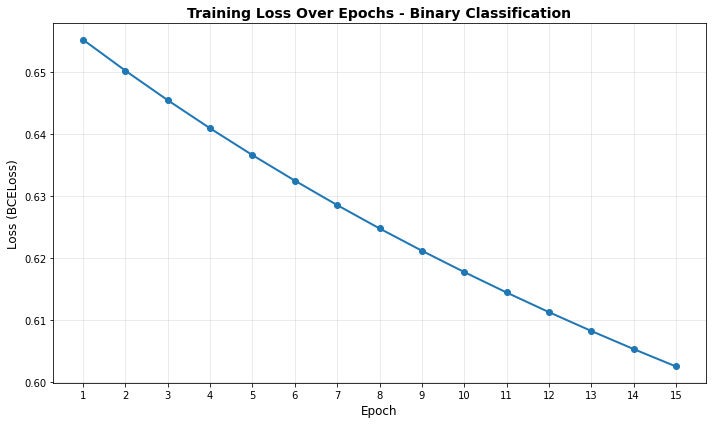


Final Model Performance:
Final Loss: 0.5998
Training Accuracy: 0.7500 (75.00%)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Step 1: Data Generation (Learnable Binary Target)
print("Step 1: Generating synthetic data...")
torch.manual_seed(42)  # For reproducibility

# Generate input features
X = torch.randn(200, 4)

# Create learnable binary target using noisy logistic model
w = torch.tensor([[0.8], [0.6], [0.7], [0.5]])
b = torch.tensor([-1.0])
noise = 0.3 * torch.randn(200, 1)
proba = torch.sigmoid(X @ w + b + noise)  # values in (0, 1)
y = (proba > 0.5).float()  # binary labels (0/1), shape (200, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution - 0s: {(y == 0).sum().item()}, 1s: {(y == 1).sum().item()}\n")


# Step 2: Model Definition (RiskNN)
class RiskNN(nn.Module):
    def __init__(self):
        super(RiskNN, self).__init__()
        self.fc1 = nn.Linear(4, 8)  # Input layer: 4 -> Hidden: 8
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)  # Hidden: 8 -> Output: 1
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


# Step 3: Model Setup (BCELoss + SGD)
print("Step 3: Setting up model, loss, and optimizer...")
model = RiskNN()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

print("Model Architecture:")
print(model)
print()


# Step 4: Training Loop
print("Step 4: Training the model...\n")
epochs = 15
loss_history = []

for epoch in range(epochs):
    # Forward pass
    preds = model(X)
    
    # Compute loss
    loss = criterion(preds, y)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Record loss
    loss_history.append(loss.item())
    
    # Print loss
    print(f"Epoch {epoch+1:02d}: loss={loss.item():.4f}")

print("\nTraining complete!")


# Step 5: Loss Visualisation
print("\nStep 5: Visualizing training loss...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (BCELoss)', fontsize=12)
plt.title('Training Loss Over Epochs - Binary Classification', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, epochs + 1))
plt.tight_layout()
plt.show()

# Final evaluation
print("\nFinal Model Performance:")
with torch.no_grad():
    final_preds = model(X)
    final_loss = criterion(final_preds, y)
    predicted_classes = (final_preds > 0.5).float()
    accuracy = (predicted_classes == y).float().mean()
    print(f"Final Loss: {final_loss.item():.4f}")
    print(f"Training Accuracy: {accuracy.item():.4f} ({accuracy.item()*100:.2f}%)")

## 1) Why is BCELoss appropriate for this task, and when would you prefer MSELoss instead?
BCELoss is appropriate because:

    We have binary classification (labels are 0 or 1)
    BCELoss is specifically designed for binary outcomes with probabilistic predictions
    It measures how well predicted probabilities match true binary labels
    It penalizes confident wrong predictions more heavily (logarithmic penalty)

MSELoss would be preferred when:

    You have regression tasks (predicting continuous values)
    Target values are not bounded between 0 and 1
    Examples: predicting house prices, temperature, stock values
    MSELoss measures squared difference between prediction and target

Key difference: BCELoss expects probabilities (0-1) and binary labels; MSELoss treats the problem as continuous value prediction.

## 2) What happens to learning if you remove the Sigmoid activation while still using BCELoss?
This would cause critical problems:

    BCELoss expects inputs in the range [0, 1] (probabilities)
    Without Sigmoid, the output can be any real number (-∞ to +∞)
    This causes numerical instability - the log() in BCELoss will fail for negative values or values > 1
    You may get NaN (Not a Number) losses or runtime errors

Solution if you remove Sigmoid:

    Use nn.BCEWithLogitsLoss() instead - it combines Sigmoid + BCELoss
    This is actually more numerically stable and preferred in practice
    It applies log-sum-exp trick to avoid numerical issues


## 3) How does increasing the learning rate for SGD (e.g., to 0.2) affect convergence and stability?
Effects of increasing learning rate from 0.05 to 0.2:

Potential benefits:

    Faster initial convergence - larger steps toward the minimum
    Fewer epochs needed to reach good performance

Risks:

    Overshooting - may jump over the optimal point
    Oscillation - loss bounces around instead of smoothly decreasing
    Divergence - loss may increase and never converge (weights explode)
    Instability - loss curve becomes erratic

Best practice: Start with moderate learning rates (0.01-0.1), monitor loss curves, and reduce if you see instability.

## 4) How does increasing the noise in label generation change the loss curve and final performance?
With more noise (e.g., changing 0.3 to 1.0):

Loss curve changes:

    Higher final loss - labels become less predictable from features
    Slower convergence - harder to find patterns in noisy data
    More fluctuation - loss bounces more between epochs
    Higher plateau - loss stabilizes at a higher value

Final performance:

    Lower accuracy - inherent noise creates irreducible error
    Underfitting risk increases - model can't capture random noise (which is good!)
    Lower confidence - predictions become less certain

Why: Noise adds randomness that no model can learn. There's a fundamental limit to how well features predict labels when noise is high.

## 5) If classes become imbalanced (e.g., 90% labels are 0), what changes could you make to the loss or data generation to address this?
Problems with imbalanced data:

    Model learns to predict majority class (always predicting 0 gives 90% accuracy!)
    Minority class gets ignored
    Misleading accuracy metric

### Solutions:
##### A) Weighted Loss:
python# Calculate class weights

pos_weight = (y == 0).sum() / (y == 1).sum()  # ratio of negatives to positives

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

This makes errors on minority class (1s) more expensive.
#### B) Balanced Sampling:
python# Oversample minority class or undersample majority class

from torch.utils.data import WeightedRandomSampler

#### C) Adjust Data Generation:
python# Change the bias term to shift class distribution

b = torch.tensor([0.0])  # instead of -1.0, makes classes more balanced
#### D) Better Metrics:

Don't rely on accuracy alone

Use: Precision, Recall, F1-Score, ROC-AUC

These metrics better capture performance on both classes

#### E) Focal Loss:

Advanced technique that automatically focuses on hard examples

Reduces weight of easy (well-classified) examples

Recommendation: Start with weighted loss (simplest) and monitor class-specific metrics, not just overall accuracy.Retry